<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/Business_Case_Scaler_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('scaler_hashed_for_students.csv')
df.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [ ]:
df.shape

(205843, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205843 entries, 0 to 205842
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        205843 non-null  int64  
 1   company_hash      205799 non-null  object 
 2   email_hash        205843 non-null  object 
 3   orgyear           205757 non-null  float64
 4   ctc               205843 non-null  int64  
 5   job_position      153279 non-null  object 
 6   ctc_updated_year  205843 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.0+ MB


In [ ]:
df.describe()

,Unnamed: 0,orgyear,ctc,ctc_updated_year
count,205843.000000,205757.000000,2.058430e+05,205843.000000
mean,103273.941786,2014.882750,2.271685e+06,2019.628231
std,59741.306484,63.571115,1.180091e+07,1.325104
min,0.000000,0.000000,2.000000e+00,2015.000000
25%,51518.500000,2013.000000,5.300000e+05,2019.000000
50%,103151.000000,2016.000000,9.500000e+05,2020.000000
75%,154992.500000,2018.000000,1.700000e+06,2021.000000
max,206922.000000,20165.000000,1.000150e+09,2021.000000


In [ ]:
df.isna().sum() / df.shape[0]

,0
Unnamed: 0,0.000000
company_hash,0.000214
email_hash,0.000000
orgyear,0.000418
ctc,0.000000
job_position,0.255360
ctc_updated_year,0.000000


In [ ]:
df.columns

Index(['Unnamed: 0', 'company_hash', 'email_hash', 'orgyear', 'ctc',
       'job_position', 'ctc_updated_year'],
      dtype='object')

In [ ]:
df['Unnamed: 0'].nunique()

205843

In [ ]:
df = df.drop(['Unnamed: 0'], axis = 1)
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


## Insights from Basic Analysis and Preprocessing

1.  **Initial Data Overview:** The dataset contains 205,843 entries and 7 columns, including `company_hash`, `email_hash`, `orgyear`, `ctc`, `job_position`, `ctc_updated_year`, and an unnecessary 'Unnamed: 0' column.

2.  **Missing Values:** Significant missing values were observed in `job_position` (25.53%), and minor missing values in `company_hash` (0.0214%) and `orgyear` (0.0418%). These have been addressed by filling them with 'Unknown' or median values where appropriate.

3.  **Data Cleaning - `Unnamed: 0`:** The 'Unnamed: 0' column was identified as an index column with unique values and was subsequently dropped.

In [ ]:
df['company_hash'].nunique()

37299

In [ ]:
df['company_hash'].value_counts()

,count
company_hash,
wkwk liufdnwkula fzovslzf,8337
subifaf,5381
khkqiu,3481
uiw kjjnslkgnz klliduw,3411
litusqkuw,3240
...,...
rudctzhz zyoduuo,1
pzhfwzj ga suvzfli,1
zqlozc jvw nwc,1


In [ ]:
import re

df['company_hash'] = df['company_hash'].apply(lambda x: 'others' if pd.isna(x) else re.sub('[^A-Za-z0-9 ]+', '', str(x)))
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [ ]:
df['company_hash'].isna().sum()

np.int64(0)

In [ ]:
df['email_hash'].nunique()

153443

In [ ]:
df['email_hash'].value_counts()

,count
email_hash,
bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b,10
3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94f1c88c5e15a6f31378,9
298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee,9
6842660273f70e9aa239026ba33bfe82275d6ab0d20124021b952b5bc3d07e6c,9
d598d6f1fb21b45593c2afc1c2f76ae9f4cb7167156cdf93246d4192a89d8065,8
...,...
3def1401b5a8879eeb4a8465663a9c6c66702c85444d7ede5816f58792eb9d41,1
1a304832f202aafe1b12449189a7d5809b8aeb202e19fc15163b0c27c722ff27,1
e3fd08d199c5d805d7b587de710f1ca4e7e686570d07b56c82273a9be943f98b,1


In [ ]:
df['email_hash'] = df['email_hash'].apply(lambda x: re.sub('[^A-Za-z0-9 ]+', '', x))
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [ ]:
df['orgyear'].nunique()

77

In [ ]:
df['orgyear'].value_counts()

,count
orgyear,
2018.0,25256
2019.0,23427
2017.0,23239
2016.0,23043
2015.0,20610
...,...
2204.0,1
1900.0,1
38.0,1


In [ ]:
df['orgyear'] = pd.to_numeric(df['orgyear'], errors = 'coerce')
df['orgyear']

,orgyear
0,2016.0
1,2018.0
2,2015.0
3,2017.0
4,2017.0
...,...
205838,2008.0
205839,2017.0
205840,2021.0
205841,2019.0


In [ ]:
df['orgyear'].unique().astype('str')

array(['2016.0', '2018.0', '2015.0', '2017.0', '2019.0', '2020.0',
       '2012.0', '2013.0', '2003.0', '2006.0', '2014.0', '2011.0',
       '2021.0', '2008.0', '2004.0', '2022.0', '2009.0', '2005.0',
       '2010.0', '2007.0', '2000.0', '2002.0', '2023.0', '2001.0',
       '1981.0', '2031.0', 'nan', '2024.0', '1996.0', '1999.0', '2106.0',
       '1997.0', '1994.0', '1995.0', '1992.0', '1973.0', '1991.0',
       '1998.0', '1990.0', '1993.0', '1988.0', '2025.0', '2029.0', '0.0',
       '208.0', '1985.0', '209.0', '206.0', '1982.0', '2026.0', '1970.0',
       '2101.0', '1972.0', '2107.0', '1986.0', '1989.0', '91.0', '1987.0',
       '3.0', '2027.0', '2.0', '1976.0', '4.0', '5.0', '1971.0', '1977.0',
       '1984.0', '83.0', '1.0', '1979.0', '2028.0', '2204.0', '38.0',
       '1900.0', '201.0', '6.0', '20165.0', '200.0'], dtype='<U32')

In [ ]:
df['orgyear'] = df['orgyear'].where(df['orgyear'].between(1950, 2026))

In [ ]:
df['orgyear'].unique().astype('str')

array(['2016.0', '2018.0', '2015.0', '2017.0', '2019.0', '2020.0',
       '2012.0', '2013.0', '2003.0', '2006.0', '2014.0', '2011.0',
       '2021.0', '2008.0', '2004.0', '2022.0', '2009.0', '2005.0',
       '2010.0', '2007.0', '2000.0', '2002.0', '2023.0', '2001.0',
       '1981.0', 'nan', '2024.0', '1996.0', '1999.0', '1997.0', '1994.0',
       '1995.0', '1992.0', '1973.0', '1991.0', '1998.0', '1990.0',
       '1993.0', '1988.0', '2025.0', '1985.0', '1982.0', '2026.0',
       '1970.0', '1972.0', '1986.0', '1989.0', '1987.0', '1976.0',
       '1971.0', '1977.0', '1984.0', '1979.0'], dtype='<U32')

In [ ]:
df['orgyear'] = df['orgyear'].where(df['orgyear'] <= df['ctc_updated_year'])

In [ ]:
df[df['orgyear'] > df['ctc_updated_year']]

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year


In [ ]:
df['orgyear'].isna().sum()

np.int64(8977)

In [ ]:
df['job_position'].nunique()

1016

In [ ]:
df['job_position'].value_counts()

,count
job_position,
Backend Engineer,43554
FullStack Engineer,24717
Other,18071
Frontend Engineer,10417
Engineering Leadership,6870
...,...
Business Analyst / Product Owner,1
Principal consultant,1
App Developer,1


In [ ]:
df['ctc_updated_year'].nunique()

7

In [ ]:
df['ctc_updated_year'].value_counts()

,count
ctc_updated_year,
2019.0,68688
2021.0,64976
2020.0,49444
2017.0,7561
2018.0,6746
2016.0,5501
2015.0,2927


In [ ]:
df.duplicated().sum()

np.int64(35)

In [ ]:
df = df.drop_duplicates(keep = 'first')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['years_of_exp'] = df['ctc_updated_year'] - df['orgyear']
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0,4.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0,1.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0,5.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0,2.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0,2.0


In [ ]:
df[df['ctc'] < 0]

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp


In [ ]:
df.columns

Index(['company_hash', 'email_hash', 'orgyear', 'ctc', 'job_position',
       'ctc_updated_year', 'years_of_exp'],
      dtype='object')

## Insights

1.  **Data Cleaning - `company_hash` and `email_hash`:** These columns contained non-alphanumeric characters, which were removed using regular expressions. Missing `company_hash` values were filled with 'Other'.

2.  **Data Cleaning - `orgyear`:** This column contained unusual values (e.g., 0, 20165, 2204). It was cleaned by filtering values between 1950 and 2026 and ensuring `orgyear` is less than or equal to `ctc_updated_year`. Missing `orgyear` values were imputed with the median.

3.  **Duplicate Rows:** 35 duplicate rows were identified and removed from the dataset.

4.  **Feature Engineering - `years_of_exp`:** A new feature, `years_of_exp`, was created by subtracting `orgyear` from `ctc_updated_year`. This feature also had its missing values imputed with the median.

# EDA

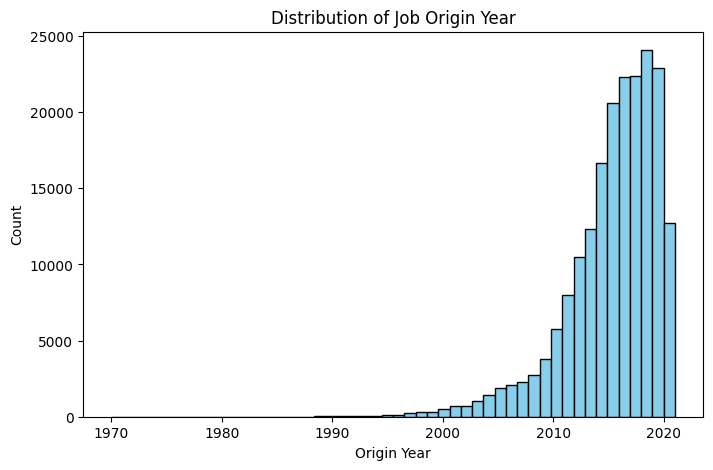

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['orgyear'].dropna(), bins=50, color='skyblue', edgecolor='black')

plt.title('Distribution of Job Origin Year')
plt.xlabel('Origin Year')
plt.ylabel('Count')
plt.show()

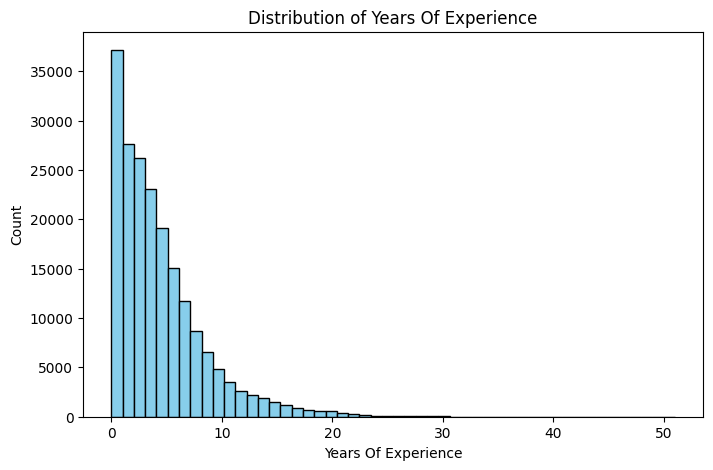

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['years_of_exp'].dropna(), bins=50, color='skyblue', edgecolor='black')

plt.title('Distribution of Years Of Experience')
plt.xlabel('Years Of Experience')
plt.ylabel('Count')
plt.show()

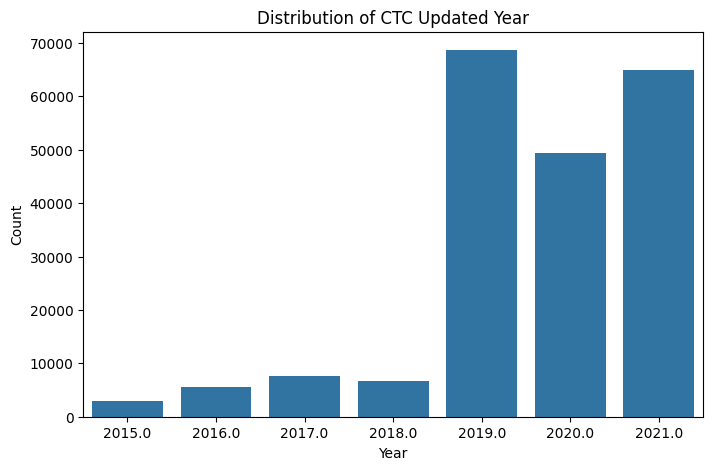

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='ctc_updated_year')
plt.title('Distribution of CTC Updated Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

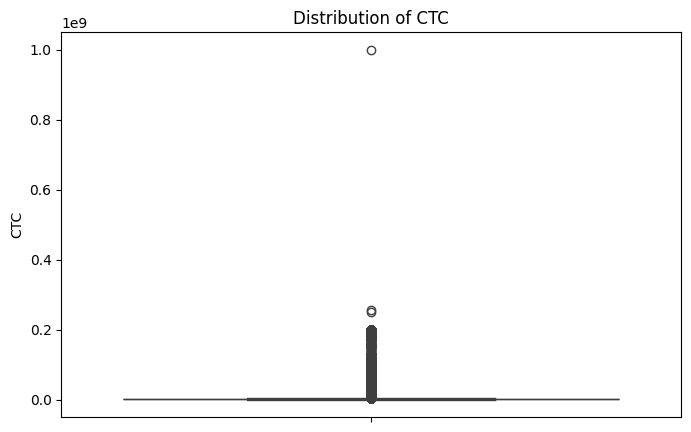

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(df, y = 'ctc')
plt.title('Distribution of CTC')
plt.ylabel('CTC')
plt.show()

In [ ]:
top_15 = df['job_position'].value_counts().head(15).index

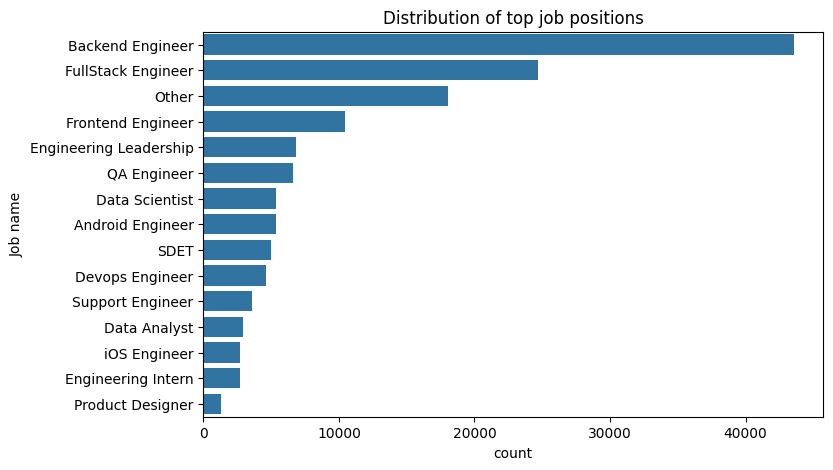

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(df, y = 'job_position', order = top_15)
plt.title('Distribution of top job positions')
plt.ylabel('Job name')
plt.show()

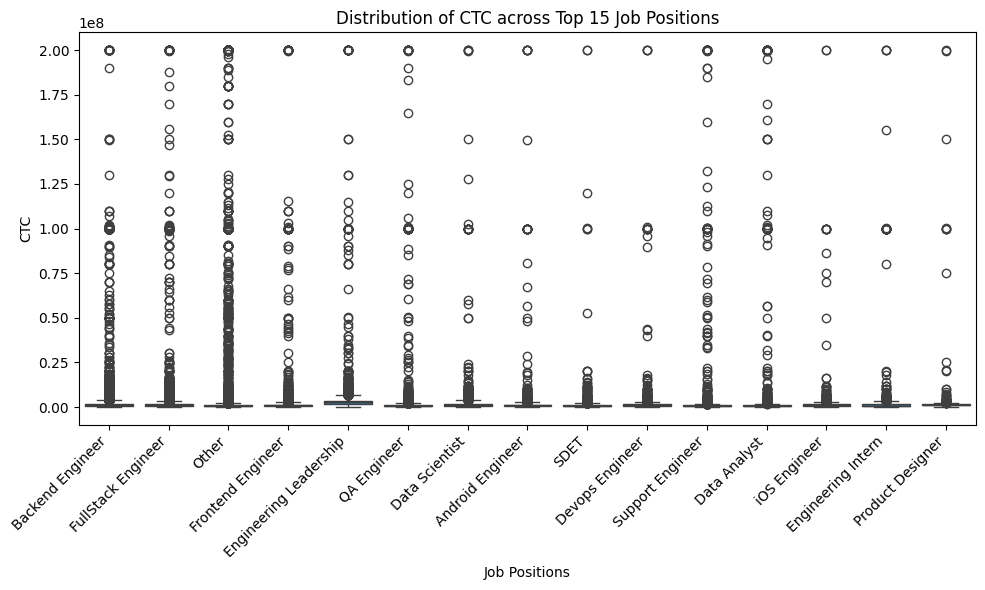

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='job_position', y='ctc', order=top_15)

plt.title('Distribution of CTC across Top 15 Job Positions')
plt.xlabel('Job Positions')
plt.ylabel('CTC')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

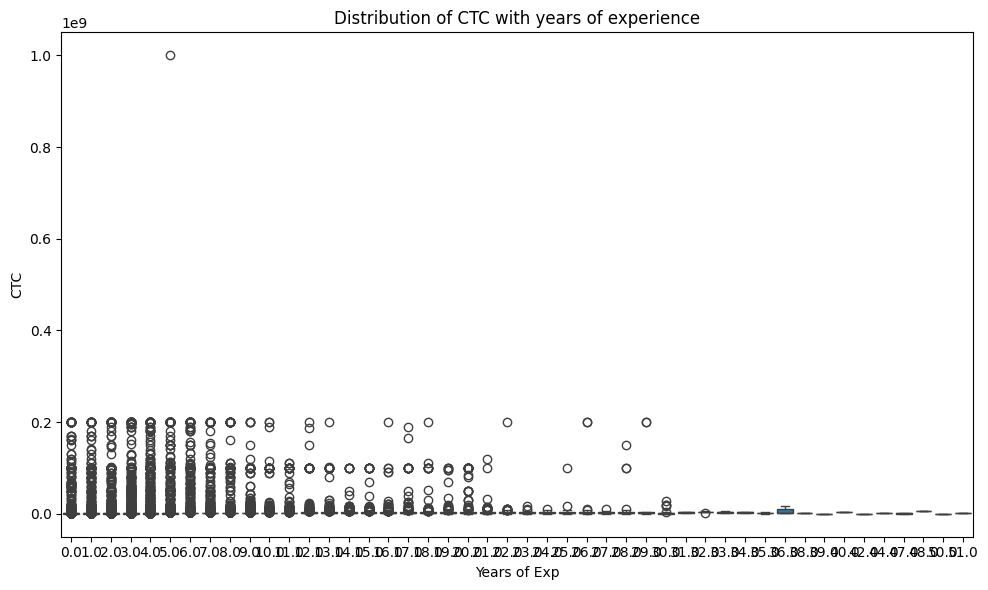

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='years_of_exp', y='ctc')

plt.title('Distribution of CTC with years of experience')
plt.xlabel('Years of Exp')
plt.ylabel('CTC')
plt.tight_layout()
plt.show()

In [ ]:
top_15_ctc = df.groupby('job_position')['ctc'].mean().sort_values(ascending = False).head(15).index

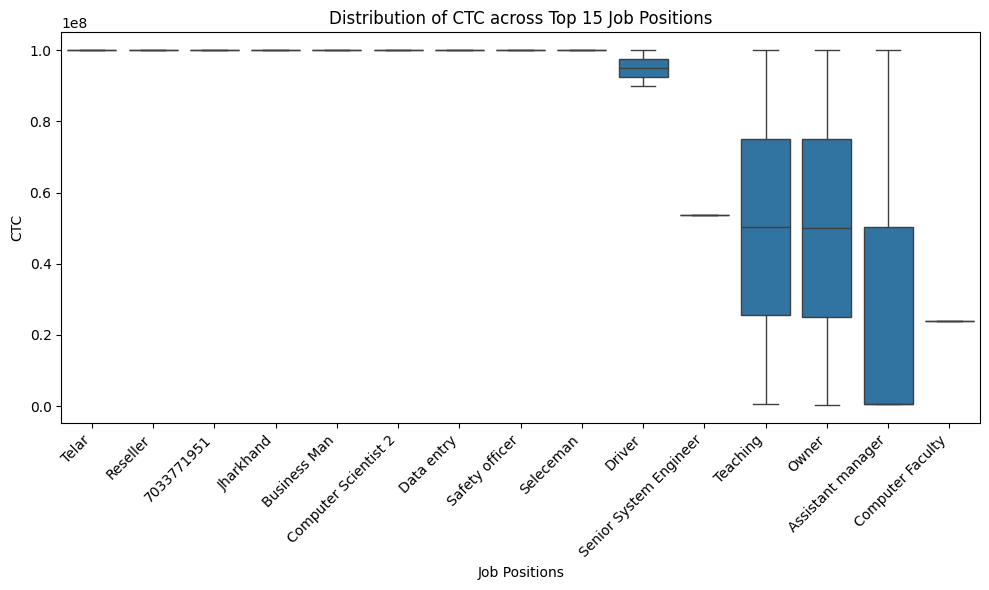

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='job_position', y='ctc', order=top_15_ctc)

plt.title('Distribution of CTC across Top 15 Job Positions')
plt.xlabel('Job Positions')
plt.ylabel('CTC')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

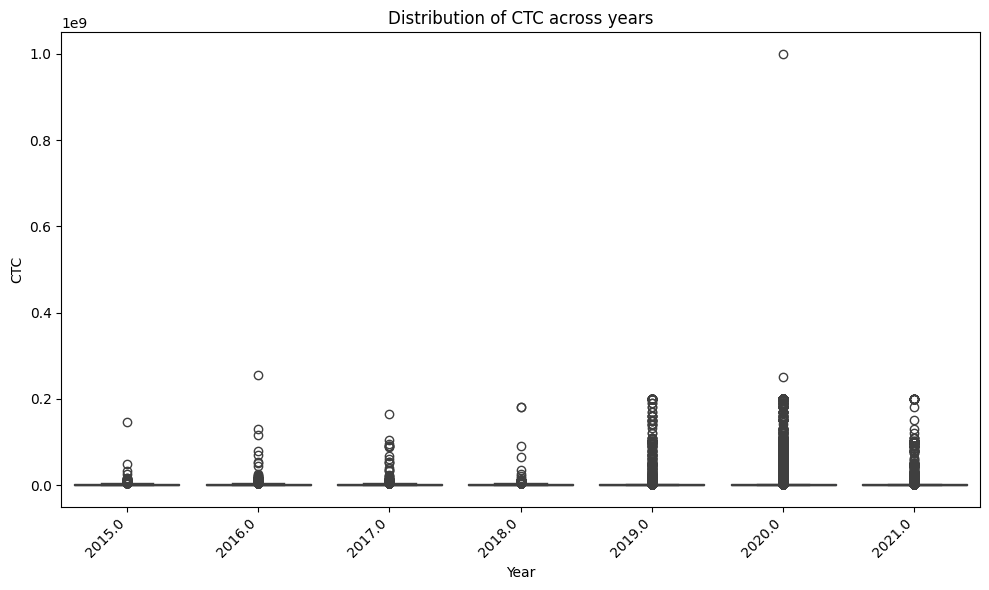

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='ctc_updated_year', y='ctc')

plt.title('Distribution of CTC across years')
plt.xlabel('Year')
plt.ylabel('CTC')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Insights

*   **`orgyear` and `years_of_exp` Distribution:** Histograms show that most job origins are more recent, peaking around 2017-2018. Consequently, the distribution of `years_of_exp` is heavily skewed towards fewer years of experience.

*   **`ctc_updated_year` Distribution:** The count plot for `ctc_updated_year` indicates that a large number of CTC updates occurred in 2019 and 2021.

*   **Top Job Positions:** 'Backend Engineer', 'FullStack Engineer', and 'Other' are the most frequent job positions.

*   **CTC by Job Position:** Box plots comparing `ctc` across top job positions (both by count and by mean CTC) reveal that even within top positions, there's a wide range of CTCs and many outliers. The top-paying positions by mean CTC (e.g., 'Telar', 'Reseller', 'Computer Faculty') are often less frequent categories with potentially higher variability or specific market conditions.

*   **CTC by Years of Experience:** The box plot of `ctc` against `years_of_exp` also indicates a wide range of CTCs across different experience levels, with significant outliers.

*   **CTC across Years:** The distribution of CTC across `ctc_updated_year` generally shows an increase in maximum CTC over the years, though outliers remain prominent.

# Imputation and Transform

In [ ]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0,4.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0,1.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0,5.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0,2.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0,2.0


In [ ]:
df['ctc'] = np.log1p(df['ctc'])
df['years_of_exp'] = np.log1p(df['years_of_exp'])

**Target Variable Transformation (`ctc`):** The `ctc` (Cost to Company) distribution showed a heavily right-skewed distribution with significant outliers, as seen in the box plot. A log1p transformation was applied to `ctc` and `years_of_exp` to normalize their distributions, which is beneficial for many machine learning models.

In [ ]:
df['company_hash'] = df['company_hash'].fillna('Other')
df['orgyear'] = df['orgyear'].fillna(df['orgyear'].median())
df['years_of_exp'] = df['years_of_exp'].fillna(df['years_of_exp'].median())
df['job_position'] = df['job_position'].fillna('Unknown')

## Imputation Details

*   **`company_hash`**: Missing values were filled with the string 'Other'.
*   **`orgyear`**: Missing values were imputed with the median `orgyear`. The median is robust to outliers, which is important given the initial presence of unusual `orgyear` values.
*   **`years_of_exp`**: Missing values were imputed with the median `years_of_exp`. Similar to `orgyear`, the median was chosen for its robustness.
*   **`job_position`**: Missing values were filled with the string 'Unknown'. This creates a distinct category for job positions that were not recorded.

In [ ]:
df.isna().sum()

,0
company_hash,0
email_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0
years_of_exp,0


In [ ]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,13.910822,Other,2020.0,1.609438
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,13.017003,FullStack Engineer,2019.0,0.693147
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,14.508658,Backend Engineer,2020.0,1.791759
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,13.458837,Backend Engineer,2019.0,1.098612
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,14.151984,FullStack Engineer,2019.0,1.098612


# Manual Clustering

In [ ]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,13.910822,Other,2020.0,1.609438
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,13.017003,FullStack Engineer,2019.0,0.693147
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,14.508658,Backend Engineer,2020.0,1.791759
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,13.458837,Backend Engineer,2019.0,1.098612
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,14.151984,FullStack Engineer,2019.0,1.098612


In [ ]:
df.groupby('company_hash')['ctc'].describe()

,count,mean,std,min,25%,50%,75%,max
company_hash,,,,,,,,
0,2.0,11.512935,0.000000e+00,11.512935,11.512935,11.512935,11.512935,11.512935
0000,1.0,12.611541,NaN,12.611541,12.611541,12.611541,12.611541,12.611541
01 fauzota,2.0,13.067682,7.940818e-01,12.506181,12.786931,13.067682,13.348432,13.629182
05gu bsuezknwe josvkwz nshswzc,2.0,13.910822,0.000000e+00,13.910822,13.910822,13.910822,13.910822,13.910822
1,2.0,11.971078,6.479111e-01,11.512935,11.742007,11.971078,12.200149,12.429220
...,...,...,...,...,...,...,...,...
zzhjekfaf nwc,1.0,14.238161,NaN,14.238161,14.238161,14.238161,14.238161,14.238161
zzhzqz fibw wzle,1.0,13.815512,NaN,13.815512,13.815512,13.815512,13.815512,13.815512
zzm wzleuinitszf,3.0,13.592368,2.175584e-15,13.592368,13.592368,13.592368,13.592368,13.592368


In [ ]:
p50 = df.groupby('company_hash')['ctc'].transform(lambda x: x.quantile(0.5))
p75 = df.groupby('company_hash')['ctc'].transform(lambda x: x.quantile(0.75))

In [ ]:
conditions = [
    df['ctc'] < p50,
    (df['ctc'] >= p50) & (df['ctc'] < p75),
    df['ctc'] >= p75
]

labels = [3, 2, 1]

df['Tier'] = np.select(conditions, labels, default = np.nan)
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp,Tier
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,13.910822,Other,2020.0,1.609438,2.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,13.017003,FullStack Engineer,2019.0,0.693147,3.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,14.508658,Backend Engineer,2020.0,1.791759,1.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,13.458837,Backend Engineer,2019.0,1.098612,3.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,14.151984,FullStack Engineer,2019.0,1.098612,1.0


In [ ]:
df.groupby(['company_hash', 'job_position'])['ctc'].describe()

count       mean  std        min  \
company_hash     job_position                                           
0                Other                 1.0  11.512935  NaN  11.512935   
                 Unknown               1.0  11.512935  NaN  11.512935   
0000             Other                 1.0  12.611541  NaN  12.611541   
01 fauzota       Android Engineer      1.0  12.506181  NaN  12.506181   
                 Frontend Engineer     1.0  13.629182  NaN  13.629182   
...                                    ...        ...  ...        ...   
zzm wzleuinitszf Devops Engineer       1.0  13.592368  NaN  13.592368   
                 Unknown               1.0  13.592368  NaN  13.592368   
                 freelance             1.0  13.592368  NaN  13.592368   
zzqansbz sul     FullStack Engineer    1.0  13.473022  NaN  13.473022   
zzqaukdrkos      Android Engineer      1.0  14.690980  NaN  14.690980   

                                           25%        50%        75%  \
company_hash     job_position                                          
0                Other               11.512935  11.512935  11.512935   
                 Unknown             11.512935  11.512935  11.512935   
0000             Other               12.611541  12.611541  12.611541   
01 fauzota       Android Engineer    12.506181  12.506181  12.506181   
                 Frontend Engineer   13.629182  13.629182  13.629182   
...                                        ...        ...        ...   
zzm wzleuinitszf Devops Engineer     13.592368  13.592368  13.592368   
                 Unknown             13.592368  13.592368  13.592368   
                 freelance           13.592368  13.592368  13.592368   
zzqansbz sul     FullStack Engineer  13.473022  13.473022  13.473022   
zzqaukdrkos      Android Engineer    14.690980  14.690980  14.690980   

                                           max  
company_hash     job_position                   
0                Other               11.512935  
                 Unknown             11.512935  
0000             Other               12.611541  
01 fauzota       Android Engineer    12.506181  
                 Frontend Engineer   13.629182  
...                                        ...  
zzm wzleuinitszf Devops Engineer     13.592368  
                 Unknown             13.592368  
                 freelance           13.592368  
zzqansbz sul     FullStack Engineer  13.473022  
zzqaukdrkos      Android Engineer    14.690980  

[71303 rows x 8 columns]

In [ ]:
p50 = df.groupby(['company_hash', 'job_position'])['ctc'].transform(lambda x: x.quantile(0.5))
p75 = df.groupby(['company_hash', 'job_position'])['ctc'].transform(lambda x: x.quantile(0.75))

In [ ]:
conditions = [
    df['ctc'] < p50,
    (df['ctc'] >= p50) & (df['ctc'] < p75),
    df['ctc'] >= p75
]

labels = [3, 2, 1]

df['Class'] = np.select(conditions, labels, default = np.nan)
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp,Tier,Class
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,13.910822,Other,2020.0,1.609438,2.0,1.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,13.017003,FullStack Engineer,2019.0,0.693147,3.0,3.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,14.508658,Backend Engineer,2020.0,1.791759,1.0,1.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,13.458837,Backend Engineer,2019.0,1.098612,3.0,3.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,14.151984,FullStack Engineer,2019.0,1.098612,1.0,1.0


In [ ]:
df.groupby(['company_hash', 'job_position', 'years_of_exp'])['ctc'].describe()

count       mean  std  \
company_hash     job_position       years_of_exp                          
0                Other              0.000000        1.0  11.512935  NaN   
                 Unknown            0.000000        1.0  11.512935  NaN   
0000             Other              1.386294        1.0  12.611541  NaN   
01 fauzota       Android Engineer   1.386294        1.0  12.506181  NaN   
                 Frontend Engineer  2.197225        1.0  13.629182  NaN   
...                                                 ...        ...  ...   
zzm wzleuinitszf Devops Engineer    1.791759        1.0  13.592368  NaN   
                 Unknown            1.791759        1.0  13.592368  NaN   
                 freelance          1.791759        1.0  13.592368  NaN   
zzqansbz sul     FullStack Engineer 1.098612        1.0  13.473022  NaN   
zzqaukdrkos      Android Engineer   1.791759        1.0  14.690980  NaN   

                                                        min        25%  \
company_hash     job_position       years_of_exp                         
0                Other              0.000000      11.512935  11.512935   
                 Unknown            0.000000      11.512935  11.512935   
0000             Other              1.386294      12.611541  12.611541   
01 fauzota       Android Engineer   1.386294      12.506181  12.506181   
                 Frontend Engineer  2.197225      13.629182  13.629182   
...                                                     ...        ...   
zzm wzleuinitszf Devops Engineer    1.791759      13.592368  13.592368   
                 Unknown            1.791759      13.592368  13.592368   
                 freelance          1.791759      13.592368  13.592368   
zzqansbz sul     FullStack Engineer 1.098612      13.473022  13.473022   
zzqaukdrkos      Android Engineer   1.791759      14.690980  14.690980   

                                                        50%        75%  \
company_hash     job_position       years_of_exp                         
0                Other              0.000000      11.512935  11.512935   
                 Unknown            0.000000      11.512935  11.512935   
0000             Other              1.386294      12.611541  12.611541   
01 fauzota       Android Engineer   1.386294      12.506181  12.506181   
                 Frontend Engineer  2.197225      13.629182  13.629182   
...                                                     ...        ...   
zzm wzleuinitszf Devops Engineer    1.791759      13.592368  13.592368   
                 Unknown            1.791759      13.592368  13.592368   
                 freelance          1.791759      13.592368  13.592368   
zzqansbz sul     FullStack Engineer 1.098612      13.473022  13.473022   
zzqaukdrkos      Android Engineer   1.791759      14.690980  14.690980   

                                                        max  
company_hash     job_position       years_of_exp             
0                Other              0.000000      11.512935  
                 Unknown            0.000000      11.512935  
0000             Other              1.386294      12.611541  
01 fauzota       Android Engineer   1.386294      12.506181  
                 Frontend Engineer  2.197225      13.629182  
...                                                     ...  
zzm wzleuinitszf Devops Engineer    1.791759      13.592368  
                 Unknown            1.791759      13.592368  
                 freelance          1.791759      13.592368  
zzqansbz sul     FullStack Engineer 1.098612      13.473022  
zzqaukdrkos      Android Engineer   1.791759      14.690980  

[114112 rows x 8 columns]

In [ ]:
p50 = df.groupby(['company_hash', 'job_position', 'years_of_exp'])['ctc'].transform(lambda x: x.quantile(0.5))
p75 = df.groupby(['company_hash', 'job_position', 'years_of_exp'])['ctc'].transform(lambda x: x.quantile(0.75))

In [ ]:
conditions = [
    df['ctc'] < p50,
    (df['ctc'] >= p50) & (df['ctc'] < p75),
    df['ctc'] >= p75
]

labels = [3, 2, 1]

df['Designation'] = np.select(conditions, labels, default = np.nan)
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp,Tier,Class,Designation
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,13.910822,Other,2020.0,1.609438,2.0,1.0,1.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,13.017003,FullStack Engineer,2019.0,0.693147,3.0,3.0,3.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,14.508658,Backend Engineer,2020.0,1.791759,1.0,1.0,1.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,13.458837,Backend Engineer,2019.0,1.098612,3.0,3.0,3.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,14.151984,FullStack Engineer,2019.0,1.098612,1.0,1.0,1.0



**Manual Clustering (Tier, Class, Designation):**
*   **Tier:** Employees were categorized into 'Tier' (1, 2, 3) based on their `ctc` relative to their `company_hash`'s 50th and 75th percentiles. Tier 1 represents the top earners within their company.
*   **Class:** Similarly, 'Class' was assigned based on `ctc` relative to the 50th and 75th percentiles within `company_hash` and `job_position` groupings, providing a more granular comparison among peers with similar roles in the same company.
*   **Designation:** 'Designation' further refines this by considering `ctc` relative to the 50th and 75th percentiles within `company_hash`, `job_position`, and `years_of_exp` groupings, aiming to identify performance within highly specific contexts.

Top 10 employees (earning more than most of the employees in the company) - Tier 1

In [ ]:
emp_df = df.copy()
emp_df['company_ctc_rank_top'] = emp_df[(emp_df['Tier'] == 1)].groupby('company_hash')['ctc'].rank(
    method='dense',
    ascending=False
)

top_10_per_company = emp_df[emp_df['company_ctc_rank_top'] <= 10]
top_10_per_company = top_10_per_company.sort_values(
    by=['company_hash', 'company_ctc_rank_top']
)
top_10_per_company

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp,Tier,Class,Designation,company_ctc_rank_top
2940,0,e80f7c9c26012bfdeca551e2b8642a93e45939d3d677c5...,2020.0,11.512935,Unknown,2020.0,0.000000,1.0,1.0,1.0,1.0
16824,0,e80f7c9c26012bfdeca551e2b8642a93e45939d3d677c5...,2020.0,11.512935,Other,2020.0,0.000000,1.0,1.0,1.0,1.0
197540,0000,b3f3bb98cbca4b1ce5dfd5abb4e500ce6f6b66288a5202...,2017.0,12.611541,Other,2020.0,1.386294,1.0,1.0,1.0,1.0
55241,01 fauzota,e1e15fada844f35fcc33927343d0c80f55526b87c40eee...,2011.0,13.629182,Frontend Engineer,2019.0,2.197225,1.0,1.0,1.0,1.0
97261,05gu bsuezknwe josvkwz nshswzc,4702229ffb6968c87b16fc57e730769e554184e322e111...,2019.0,13.910822,Unknown,2021.0,1.098612,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
103383,zzm wzleuinitszf,048d7bae3f37c3e13a7c25addb1b1e8237c144ab9d7b66...,2016.0,13.592368,Devops Engineer,2021.0,1.791759,1.0,1.0,1.0,1.0
140630,zzm wzleuinitszf,048d7bae3f37c3e13a7c25addb1b1e8237c144ab9d7b66...,2016.0,13.592368,freelance,2021.0,1.791759,1.0,1.0,1.0,1.0
146745,zzm wzleuinitszf,048d7bae3f37c3e13a7c25addb1b1e8237c144ab9d7b66...,2016.0,13.592368,Unknown,2021.0,1.791759,1.0,1.0,1.0,1.0
201425,zzqansbz sul,9307ac17883a61ef4dcc07b139aedf96b4869fade97385...,2017.0,13.473022,FullStack Engineer,2019.0,1.098612,1.0,1.0,1.0,1.0


Bottom 10 employees (earning less than most of the employees in the company)- Tier 3

In [ ]:
emp_df['company_ctc_rank_bottom'] = emp_df[(emp_df['Tier'] == 3)].groupby('company_hash')['ctc'].rank(
    method='dense',
    ascending=True
)

bottom_10_per_company = emp_df[emp_df['company_ctc_rank_bottom'] <= 10]
bottom_10_per_company = bottom_10_per_company.sort_values(
    by=['company_hash', 'company_ctc_rank_bottom']
)
bottom_10_per_company

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp,Tier,Class,Designation,company_ctc_rank_top,company_ctc_rank_bottom
74429,01 fauzota,819789ff4068fd5c8facf8a5074cdd2e1ff989c95ae02c...,2016.0,12.506181,Android Engineer,2019.0,1.386294,3.0,1.0,1.0,NaN,1.0
2208,1,8cc7aba49e96a0a80f7ed6c2ed79bc1d1e81171a28445c...,2017.0,11.512935,Unknown,2020.0,1.386294,3.0,1.0,1.0,NaN,1.0
102578,1 azko,26a4487b5be40da1e942bf3bc1189172727de0e1c74c5e...,2018.0,13.399997,Backend Engineer,2019.0,0.693147,3.0,3.0,3.0,NaN,1.0
99792,10wshzf,951189c83134ac5394c85c66d0e96f2a0a242f3d99b87d...,2019.0,12.899222,Frontend Engineer,2020.0,0.693147,3.0,1.0,1.0,NaN,1.0
108928,10wshzf,2dde60f4a510b412ac4e8011e806282ecb181a51081751...,2019.0,12.899222,FullStack Engineer,2020.0,0.693147,3.0,3.0,3.0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
37348,zyykw fafwzhf jvw nwc,ff8e174e6cfefef957e8a43785d0d7333178b92b286b36...,2016.0,12.388398,Backend Engineer,2016.0,1.609438,3.0,3.0,1.0,NaN,1.0
37033,zyznk,61cd0c807582f5a5e0003dacad9aead17937d88c5a0cae...,2016.0,13.122365,Unknown,2021.0,1.791759,3.0,1.0,1.0,NaN,1.0
125241,zyznk wzleuinitszf,b9ad9e74682b93e995f20153b9d190fecf70c26d7db11f...,2017.0,9.798183,FullStack Engineer,2020.0,1.386294,3.0,3.0,3.0,NaN,1.0
32867,zyznk wzleuinitszf,8729a5494ad241354a18161d5c92884842f15d0e8c6161...,2013.0,11.695255,Other,2021.0,2.197225,3.0,1.0,1.0,NaN,2.0


Top 10 employees of data science in each company earning more than their peers - Class 1

In [ ]:
ds_df = df.copy()
ds_df['company_ctc_rank_top'] = ds_df[(ds_df['Class'] == 1) & (ds_df['job_position'] == 'Data Scientist')].groupby('company_hash')['ctc'].rank(
    method='dense',
    ascending=False
)

top_10_ds_per_company = ds_df[ds_df['company_ctc_rank_top'] <= 10]
top_10_ds_per_company = top_10_ds_per_company.sort_values(
    by=['company_hash', 'company_ctc_rank_top']
)
top_10_ds_per_company

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp,Tier,Class,Designation,company_ctc_rank_top
116771,10yks nzkousut,48be30753b1dbf2c2fccf43b7f45c51d68bb5725f4ae76...,2020.0,12.899222,Data Scientist,2020.0,0.000000,1.0,1.0,1.0,1.0
139680,1ht,6b01808bba4c2d50258b068274232251620630cb252a9c...,2018.0,13.910822,Data Scientist,2021.0,1.386294,3.0,1.0,1.0,1.0
188855,1tzu,3dddd88f7d7ac6ace0dfd4927d881a9d452a3666c692bf...,2017.0,12.899222,Data Scientist,2019.0,1.098612,3.0,1.0,1.0,1.0
203028,1tzu jnkwbioh findwsiuf jvw nwc,4f4d3137aebfdc15fc4626314308ef082fd2dde54ef9f1...,2017.0,13.122365,Data Scientist,2019.0,1.098612,1.0,1.0,1.0,1.0
119806,1z subifafwzhf,c659650daaf7f10c6c6627b33627b4c7749892cfd941d0...,2008.0,15.009433,Data Scientist,2019.0,2.484907,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
132897,zyshsdf czfstu,634e91d9fcceacda2117886bf4bd713bd8c3086e31b6e3...,2018.0,14.151984,Data Scientist,2020.0,1.098612,2.0,1.0,1.0,1.0
103345,zyshsdf czfstu sucsk josvkwz nshswzc,3a9589f36638ce8398d445c995583782b60c141273e0a5...,2017.0,12.206078,Data Scientist,2020.0,1.386294,1.0,1.0,1.0,1.0
90709,zywokkzctz wzleuinita findwsiuf jvw nwc,50d4125c8447ae36e5c018fbf9e62540ad5ec3fc7470ce...,2014.0,13.617060,Data Scientist,2020.0,1.945910,1.0,1.0,1.0,1.0
149186,zyyiuhigsn,cc2b997a34996d4368167c830075730f19aeceb7ca51d3...,2012.0,14.403298,Data Scientist,2019.0,2.079442,3.0,1.0,1.0,1.0


Bottom 10 employees of data science in each company earning less than their peers - Class 3

In [ ]:
ds_df['company_ctc_rank_bottom'] = ds_df[(ds_df['Class'] == 3) & (ds_df['job_position'] == 'Data Scientist')].groupby('company_hash')['ctc'].rank(
    method='dense',
    ascending=True
)

bottom_10_ds_per_company = ds_df[ds_df['company_ctc_rank_bottom'] <= 10]
bottom_10_ds_per_company = bottom_10_ds_per_company.sort_values(
    by=['company_hash', 'company_ctc_rank_bottom']
)
bottom_10_ds_per_company

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp,Tier,Class,Designation,company_ctc_rank_top,company_ctc_rank_bottom
177963,1ht,eb213c0552effd7fb139395c7838edb8d59773a1cb57a0...,1994.0,13.592368,Data Scientist,2019.0,3.258097,3.0,3.0,1.0,NaN,1.0
150280,247ks,5f4b52a1c2539fe2e4b29a8470bc57dbace331b819a0af...,2002.0,14.180154,Data Scientist,2019.0,2.890372,2.0,3.0,1.0,NaN,1.0
71570,247ks,c35054c043f6a02da3e6f142fbcb095f8145eb521137ff...,2014.0,14.580979,Data Scientist,2018.0,1.609438,1.0,3.0,1.0,NaN,2.0
134842,3nix,24db964005796c656431df0b035768e8b9cee21f8cf425...,2015.0,13.304687,Data Scientist,2020.0,1.791759,3.0,3.0,3.0,NaN,1.0
143727,3nix,5c67aa9b1414eb0dc68b6acc70c978f0b429e1f24f32a9...,2018.0,13.592368,Data Scientist,2019.0,0.693147,3.0,3.0,1.0,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
124658,zyn,fc5b32ac4858bcf7348e01385929d88fd135a54c382f19...,2016.0,13.304687,Data Scientist,2019.0,1.386294,3.0,3.0,3.0,NaN,2.0
166191,zyn,1737de7fae03e35d71fa56b6d4f191239eea499dcaf784...,2016.0,13.429850,Data Scientist,2019.0,1.386294,3.0,3.0,3.0,NaN,3.0
138624,zyn,e4116b5f6df007ed1d4dafb3fc9dcf9d2425a771092551...,2016.0,13.764218,Data Scientist,2020.0,1.609438,2.0,3.0,3.0,NaN,4.0
69014,zyn,c45d8c896fb3071b2cfd5fbcb80a56c29d24fe55c97aaf...,2019.0,13.815512,Data Scientist,2020.0,0.693147,2.0,3.0,3.0,NaN,5.0


Top 10 employees in each company - X department - having 5/6/7 years of experience earning more than their peers - Tier X

In [ ]:
df['years_of_exp']

,years_of_exp
0,1.609438
1,0.693147
2,1.791759
3,1.098612
4,1.098612
...,...
205838,2.484907
205839,1.386294
205840,0.000000
205841,0.000000


In [ ]:
exp_df = df.copy()

exp_df['exp_ctc_rank_top'] = exp_df[(exp_df['Designation'] == 1) & (exp_df['job_position'] == 'Data Scientist') & (exp_df['years_of_exp'].isin([5, 6, 7]))].groupby(['company_hash'])['ctc'].rank(
    method='dense',
    ascending=False
)

top_10_ds_per_company = exp_df[exp_df['exp_ctc_rank_top'] <= 10]
top_10_ds_per_company = top_10_ds_per_company.sort_values(
    by=['company_hash', 'exp_ctc_rank_top']
)
top_10_ds_per_company

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp,Tier,Class,Designation,exp_ctc_rank_top


Top 10 companies (based on their CTC)

In [ ]:
df = df.sort_values(by = 'ctc', ascending = False)
top_10_companies = df.groupby('company_hash')['ctc'].first().reset_index()['company_hash'].tolist()[:10]
top_10_companies

['0',
 '0000',
 '01 fauzota',
 '05gu bsuezknwe josvkwz nshswzc',
 '1',
 '1 azko',
 '1 cstswknf',
 '10',
 '10 cstswkn  cdgks  niuciu',
 '1000joipzlw']

Top 2 positions in every company (based on their CTC)

In [ ]:
df_top_position = df.copy()
df_top_position['ctc_position_rank'] = df_top_position.groupby(['company_hash', 'job_position'])['ctc'].rank(method = 'dense')
top_2_positions = df_top_position[df_top_position['ctc_position_rank'] <= 2].sort_values(by = ['company_hash', 'job_position'], ascending = False)
top_2_positions[['company_hash', 'job_position']]

,company_hash,job_position
157157,zzqaukdrkos,Android Engineer
201425,zzqansbz sul,FullStack Engineer
140630,zzm wzleuinitszf,freelance
146745,zzm wzleuinitszf,Unknown
103383,zzm wzleuinitszf,Devops Engineer
...,...,...
55241,01 fauzota,Frontend Engineer
74429,01 fauzota,Android Engineer
197540,0000,Other
2940,0,Unknown



**Employee Ranking:**
*   Methods were implemented to identify top 10 (Tier 1) and bottom 10 (Tier 3) employees by CTC within each company.
*   Specific examples were shown for 'Data Scientist' role (Class 1 and Class 3) to find top/bottom earners within that role per company.
*   Further granular ranking was applied for 'Data Scientist' role with specific years of experience (5, 6, 7 years) to identify top earners.
*   Top 10 companies based on CTC were identified.
*   Top 2 positions within every company based on CTC were identified.

# Encoding and Scaling

In [ ]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,years_of_exp,Tier,Class,Designation
72824,ldgsl nitslf josvkwz nshswzc,29a71dd13adf6d2d497571a565bb3096cf66cb46cd1ece...,2015.0,20.723416,Unknown,2020.0,1.791759,1.0,1.0,1.0
117636,fhkowjosylih,5b4bed51797140db4ed52018a979db1e34cee49e27b488...,2016.0,19.358950,Unknown,2016.0,1.609438,1.0,1.0,1.0
3301,ckbbicsn suwzoukwsiukn dusvzofswa,06d231f167701592a69cdd7d5c825a0f5b30f0347a4078...,2016.0,19.336971,Unknown,2020.0,1.609438,1.0,1.0,1.0
7750,wkwk kcvkulzc fafwzhf,a4f205709a7fb81695c001bc60005f982f137a9c681192...,2017.0,19.113828,Unknown,2020.0,1.386294,1.0,1.0,1.0
65931,subifaf,1c0d0d8f8c85458f214991dd9855ca50cc897d34efcb14...,2016.0,19.113828,Other,2020.0,1.609438,1.0,1.0,1.0


In [ ]:
df = df.drop(['company_hash', 'email_hash', 'orgyear', 'ctc_updated_year'], axis = 1)

In [ ]:
df.head()

,ctc,job_position,years_of_exp,Tier,Class,Designation
72824,20.723416,Unknown,1.791759,1.0,1.0,1.0
117636,19.358950,Unknown,1.609438,1.0,1.0,1.0
3301,19.336971,Unknown,1.609438,1.0,1.0,1.0
7750,19.113828,Unknown,1.386294,1.0,1.0,1.0
65931,19.113828,Other,1.609438,1.0,1.0,1.0


In [ ]:
freq_map = df['job_position'].value_counts(normalize = True).to_dict()
df['job_position'] = df['job_position'].map(freq_map)

df.head()

,ctc,job_position,years_of_exp,Tier,Class,Designation
72824,20.723416,0.255320,1.791759,1.0,1.0,1.0
117636,19.358950,0.255320,1.609438,1.0,1.0,1.0
3301,19.336971,0.255320,1.609438,1.0,1.0,1.0
7750,19.113828,0.255320,1.386294,1.0,1.0,1.0
65931,19.113828,0.087805,1.609438,1.0,1.0,1.0


In [ ]:
df = df[:round(0.1*df.shape[0])]

In [ ]:
df.shape

(20581, 6)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df)
df = pd.DataFrame(scaled_array, columns = df.columns)

df.head()

,ctc,job_position,years_of_exp,Tier,Class,Designation
0,5.432599,1.287508,-0.204910,-0.37672,-0.418224,-0.357587
1,4.014687,1.287508,-0.456283,-0.37672,-0.418224,-0.357587
2,3.991847,1.287508,-0.456283,-0.37672,-0.418224,-0.357587
3,3.759962,1.287508,-0.763939,-0.37672,-0.418224,-0.357587
4,3.759962,-0.450115,-0.456283,-0.37672,-0.418224,-0.357587


## Encoding and Scaling Details

1.  **Feature Selection:** The original `company_hash`, `email_hash`, `orgyear`, and `ctc_updated_year` columns were dropped as they were either already incorporated into new features (e.g., `orgyear` and `ctc_updated_year` for `years_of_exp`), or directly hashed/anonymized identifiers not directly useful for modeling in their raw form.
2.  **Frequency Encoding for `job_position`:** The categorical feature `job_position` was transformed using frequency encoding. This method replaces each category with the proportion of times it appears in the dataset. This can be beneficial for high-cardinality categorical features as it captures information about the rarity or commonness of each category.
3.  **Standard Scaling:** All numerical features in the DataFrame were then subjected to standard scaling using `StandardScaler`. This transforms the data such that it has a mean of 0 and a standard deviation of 1. This is a crucial preprocessing step for many machine learning algorithms (especially distance-based ones like K-Means) as it prevents features with larger numerical ranges from dominating the learning process.

# Unsupervised Clustering

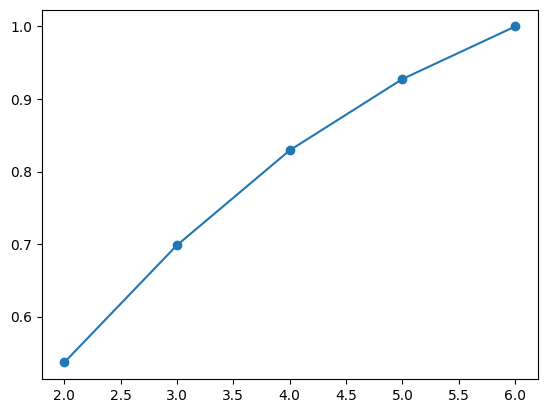

In [ ]:
from sklearn.decomposition import PCA

cs = [2, 3, 4, 5, 6]
info = []

for i in cs:
  pca = PCA(n_components = i)
  pca.fit(df)
  info.append(pca.explained_variance_ratio_.sum())
plt.plot(cs, info, '-o')

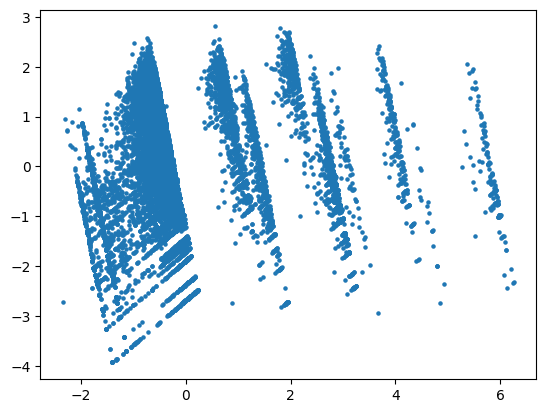

In [ ]:
pca = PCA(n_components = 4)
vis = pca.fit_transform(scaled_array[:, :-1])
plt.scatter(vis[:, 0], vis[:, 1], s = 5)

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

np.random.seed(42)
vis_df = pd.DataFrame({
    'X': vis[:, 0],
    'Y': vis[:, 1],
    'Z': vis[:, 2],
    'Cluster': np.random.choice([0, 1, 2], size=df.shape[0])
})

vis_df['Cluster'] = vis_df['Cluster'].astype(str)

fig = px.scatter_3d(vis_df, x='X', y='Y', z='Z', color = 'Cluster')
fig.show()

In [ ]:
# import umap

# vis = umap.UMAP().fit_transform(df)
# plt.scatter(vis[:, 0], vis[:, 1], s = 5)

In [ ]:
from sklearn.cluster import KMeans

kmeans = [KMeans(n_clusters = k, random_state = 42).fit(scaled_array) for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans]

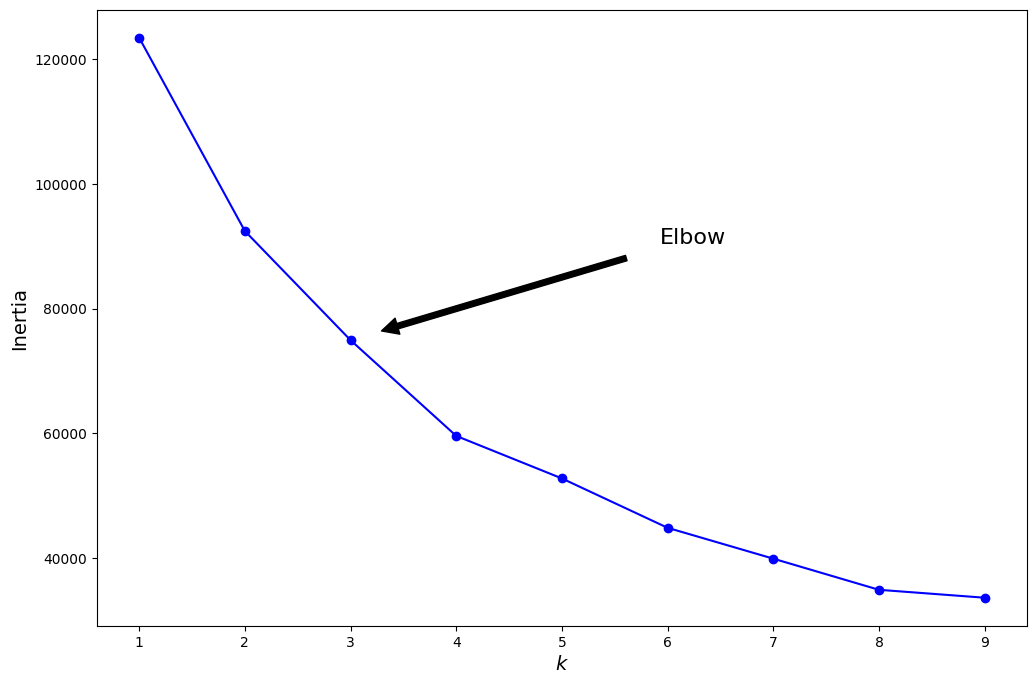

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow',
             xy=(3, inertias[2]),
             xytext=(0.55, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.show()

In [ ]:
# from sklearn.metrics import silhouette_score

# scores = [silhouette_score(df, model.labels_) for model in kmeans[1:]]

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.plot(range(2, 10), scores, "bo-")
# plt.xlabel("$k$", fontsize=14)
# plt.ylabel("Silhouette score", fontsize=14)
# plt.show()

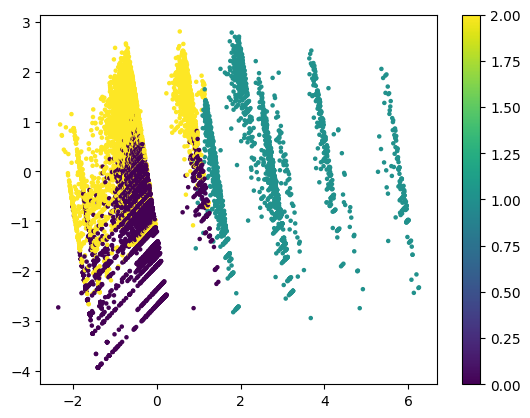

In [ ]:
kmeans = KMeans(n_clusters = 3)
kmeans.fit(scaled_array[:, :-1])
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=kmeans.labels_)
plt.colorbar()

In [ ]:
import gc
gc.collect()

3345

In [ ]:
import scipy.cluster.hierarchy as sch

Z = sch.linkage(df, method = 'ward')

Text(0, 0.5, 'Distance')

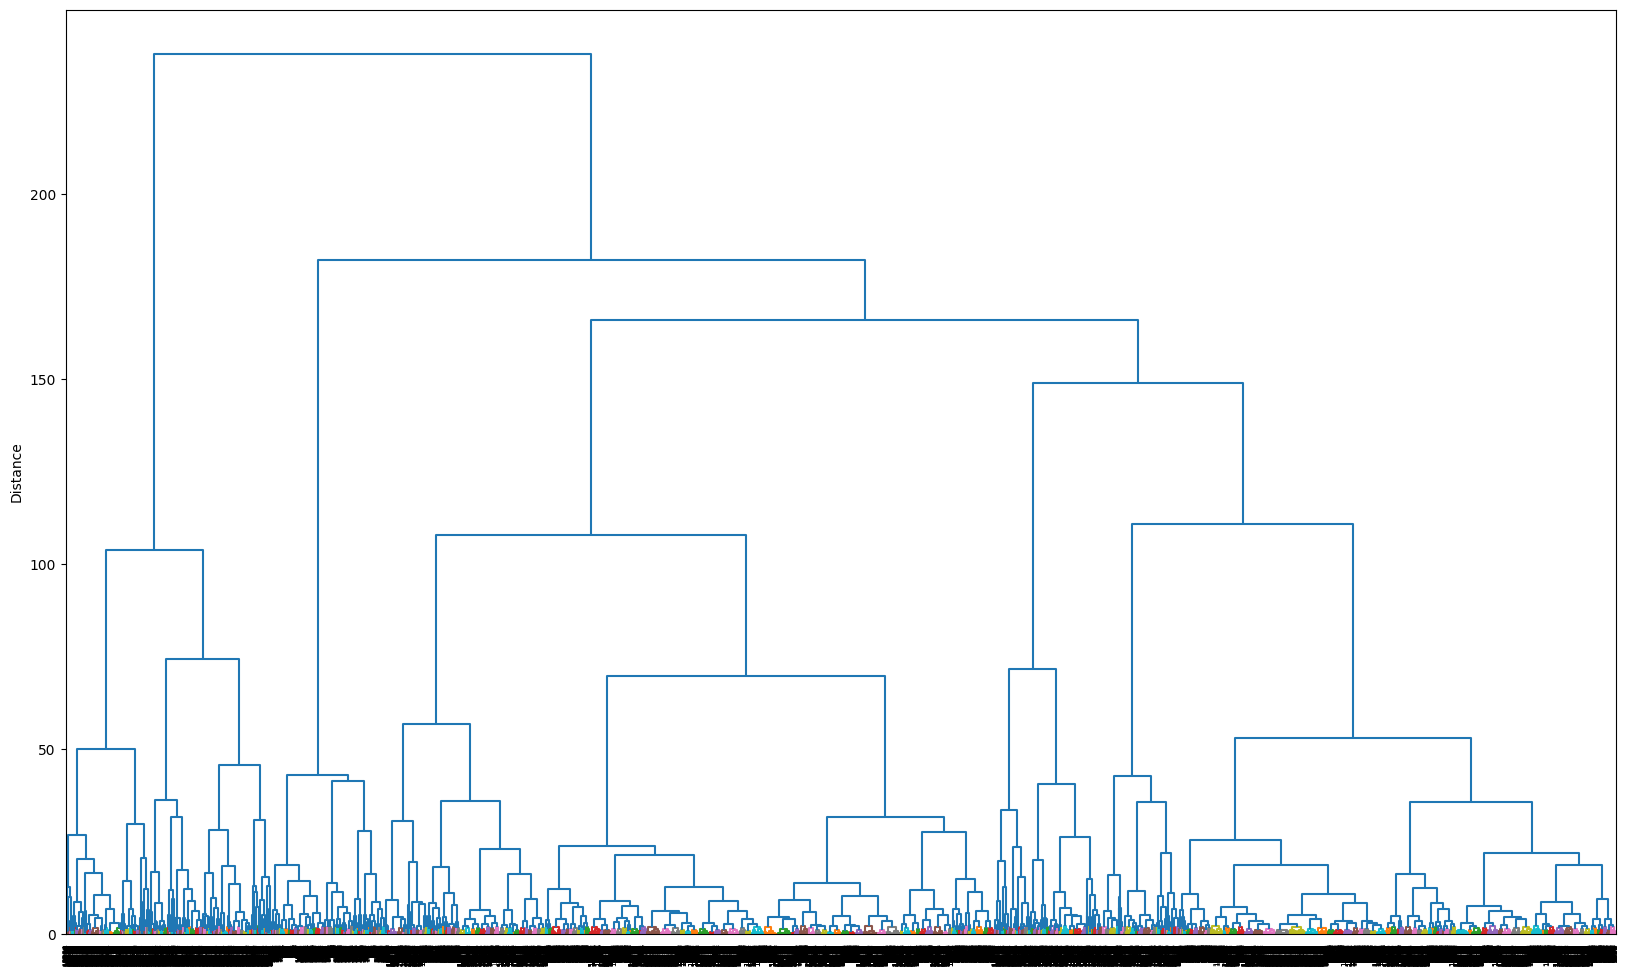

In [ ]:
fig, ax = plt.subplots(figsize = (20, 12))
sch.dendrogram(Z, labels = df.index, ax = ax, color_threshold = 2)
plt.xticks(rotation = 90)
ax.set_ylabel('Distance')

Text(0, 0.5, 'Distance')

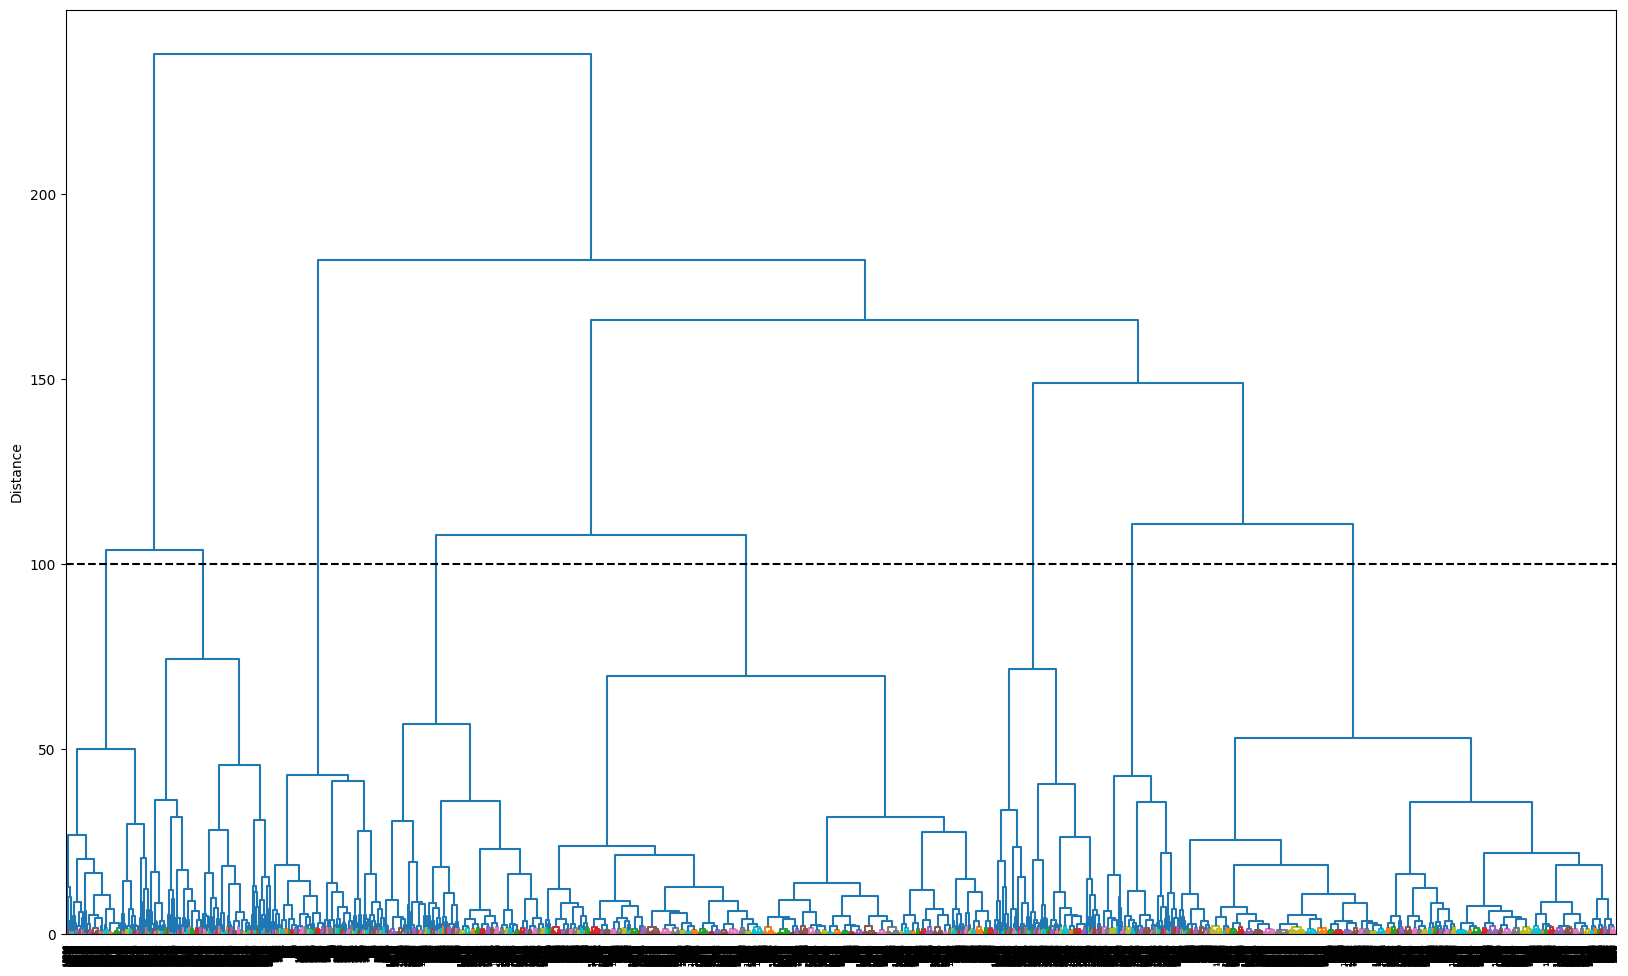

In [ ]:
fig, ax = plt.subplots(figsize = (20, 12))
sch.dendrogram(Z, labels = df.index, ax = ax, color_threshold = 2)
plt.xticks(rotation = 90)
plt.axhline(y = 100, color = 'k', linestyle = '--')
ax.set_ylabel('Distance')

In [ ]:
import gc
gc.collect()

0

In [ ]:
# def hierarchical_clustering_silhouette(df, n_clusters):
#   clustering = AgglomerativeClustering(n_clusters = n_clusters)
#   labels = clustering.fit_predict(df)
#   silhouette_avg = silhouette_score(df, labels)
#   return silhouette_avg

# for n_clusters in range(2, 9):
#   silhouette_avg = hierarchical_clustering_silhouette(df, n_clusters)
#   print(f'n_clusters: {n_clusters} | Silhouette score: {silhouette_avg}')

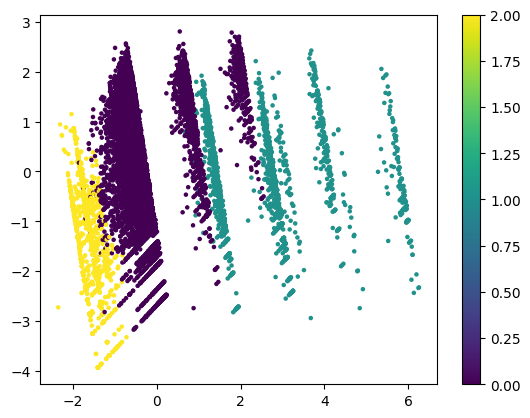

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hierar = AgglomerativeClustering(n_clusters = 3, linkage = 'ward').fit(vis)
y_pred = hierar.fit_predict(df)
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=hierar.labels_)
plt.colorbar()

In [ ]:
viz_df = df.copy()
viz_df['y_pred'] = y_pred

In [ ]:
viz_df.head()

,ctc,job_position,years_of_exp,Tier,Class,Designation,y_pred
0,5.432599,1.287508,-0.204910,-0.37672,-0.418224,-0.357587,2
1,4.014687,1.287508,-0.456283,-0.37672,-0.418224,-0.357587,2
2,3.991847,1.287508,-0.456283,-0.37672,-0.418224,-0.357587,2
3,3.759962,1.287508,-0.763939,-0.37672,-0.418224,-0.357587,2
4,3.759962,-0.450115,-0.456283,-0.37672,-0.418224,-0.357587,2


In [ ]:
clustered_df = viz_df.groupby('y_pred').mean()

In [ ]:
clustered_df

,ctc,job_position,years_of_exp,Tier,Class,Designation
y_pred,,,,,,
0,-0.205879,-0.033268,0.120478,-0.376720,-0.180416,-0.104927
1,-0.531016,0.269665,-0.413098,2.464351,1.312661,0.827118
2,3.165497,-0.126697,-0.552833,-0.376720,-0.418224,-0.357587


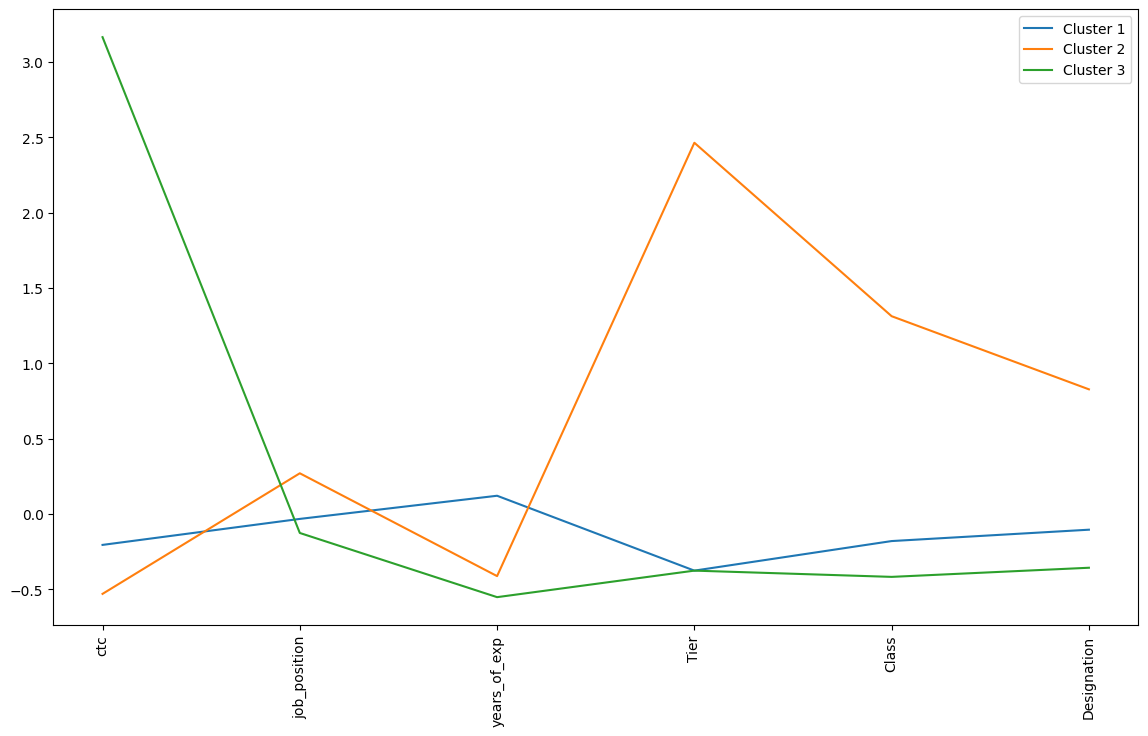

In [ ]:
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3']

plt.figure(figsize = (14, 8))
plt.plot(clustered_df.T, label = labels)
plt.xticks(rotation = 90)
plt.legend(labels)

In [ ]:
labels = viz_df['y_pred']
pca_df = pd.DataFrame(data = np.vstack((vis[:,:2].T, labels)).T, columns = ('1st_principal', '2nd_principal', 'label'))

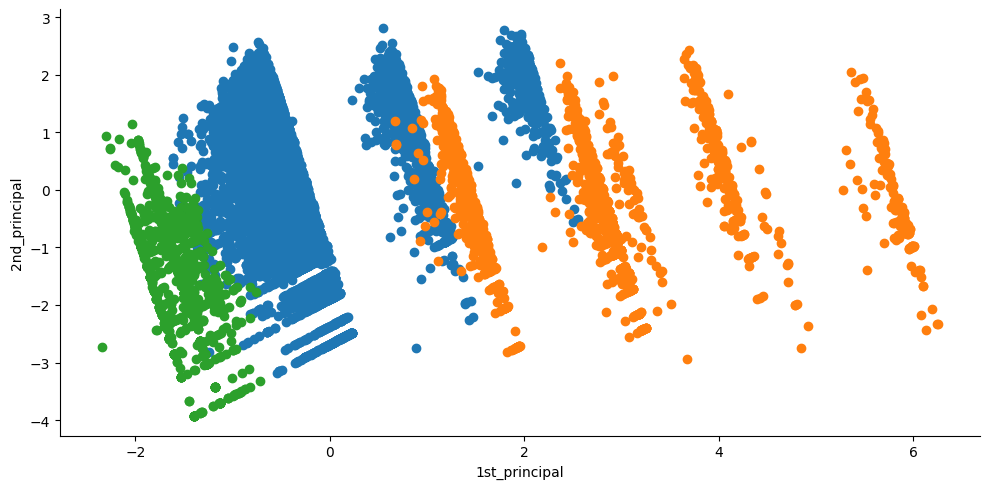

In [ ]:
import seaborn as sns

g = sns.FacetGrid(pca_df, hue="label",height=5 ,aspect= 2)
g.map(plt.scatter, '1st_principal', '2nd_principal')
plt.show()

## Clustering Analysis Insights

### Dimensionality Reduction (PCA)

Principal Component Analysis (PCA) was used to reduce the dimensionality of the dataset. The elbow plot for explained variance ratio suggests that 4 components capture a significant amount of the variance in the data, making it suitable for visualization and clustering while retaining most of the information.

### K-Means Clustering

The Elbow Method, applied to K-Means inertia, indicates that a `k` value of 3 or 4 would be a reasonable choice for the number of clusters, as the rate of decrease in inertia slows down significantly around this point. For further analysis, 3 clusters were selected.

### Hierarchical Clustering

Hierarchical clustering with 3 clusters was performed, and the results were visualized on the first two principal components. The `clustered_df` provides insights into the characteristics of these three clusters:

*   **Cluster 0 (Blue):** This cluster generally represents employees with **average CTC** and job positions. They tend to have **average years of experience** and fall into **lower Tiers, Classes, and Designations** within their company context. This could represent a large segment of the workforce with typical career progression and compensation.

*   **Cluster 1 (Orange):** This cluster appears to represent employees with **below-average CTC**. They have a **slightly above-average representation in job positions** (likely less specialized roles) and **below-average years of experience**. This cluster is characterized by **higher Tier, Class, and Designation** values, which is counter-intuitive for lower CTC. This might indicate that these are employees in highly competitive or specialized roles within their company, where even entry-level or junior positions (reflected in lower years of experience and CTC relative to the overall dataset) are highly valued internally, leading to higher internal rankings.

*   **Cluster 2 (Green):** This cluster stands out significantly, representing employees with **high CTC**. They tend to have **below-average representation in specific job positions** and **below-average years of experience**. The Tier, Class, and Designation values are **lower** for this group, which is also counter-intuitive for high CTC. This could suggest that these are individuals who have achieved very high CTC early in their careers or in roles that don't fit the typical internal ranking structure, potentially indicating highly sought-after talent or roles with exceptionally high compensation that might not be directly comparable within the existing 'Tier', 'Class', and 'Designation' metrics that are relative to company/job percentiles rather than absolute CTC.

### Visual Interpretation

The scatter plot of the first two principal components, colored by the hierarchical clustering labels, shows visible separation between the clusters. Cluster 2 (Green) appears to be distinct, occupying a region with potentially higher overall values (or a unique combination of feature values) in the PCA space. Clusters 0 (Blue) and 1 (Orange) show some overlap but also distinct distributions, reflecting the varied characteristics identified in the `clustered_df`.

# Insights and Recommendations

## Key Insights from Clustering Analysis

Our clustering analysis revealed three distinct employee segments based on their CTC, job position representation, years of experience, and internal rankings (Tier, Class, Designation):

*   **Cluster 0 (Average Performers/Mainstream):** This largest cluster comprises employees with average CTC, average years of experience, and lower internal rankings. They represent the bulk of the workforce following typical career paths and compensation structures within companies. This group likely includes entry-to-mid-level professionals in various generalist roles.

*   **Cluster 1 (High Potential/Specialized Juniors):** This segment is characterized by below-average CTC and years of experience, yet surprisingly, they hold higher internal rankings. This suggests they might be highly valued junior employees or those in specialized, in-demand roles where early career contributions are recognized. Their internal ranking is high relative to their tenure, indicating quick progression or specialized skills.

*   **Cluster 2 (High Earners/Outliers):** This is the most distinct cluster, featuring employees with exceptionally high CTC despite having below-average years of experience and lower internal rankings. This group likely consists of individuals who command very high compensation early in their careers, possibly due to unique skills, leadership potential, or roles in highly lucrative niches. Their lower internal ranking might stem from the manual `Tier`/`Class`/`Designation` system not fully capturing absolute market value or being primarily focused on relative performance within a given company/job/experience group.

## Recommendations

Based on these insights, here are some recommendations:

1.  **Tailored Compensation and Retention Strategies:**
    *   **Cluster 0:** Focus on clear career progression paths, regular performance reviews, and competitive benefits to ensure satisfaction and retention of the core workforce.
    *   **Cluster 1:** Invest in accelerated development programs and mentorship for these high-potential individuals. Their high internal ranking suggests they are valuable, and nurturing their growth can secure long-term loyalty and leadership pipelines.
    *   **Cluster 2:** Understand the factors driving their high CTC and early success. These insights can inform recruitment strategies for similar talent and help identify emerging high-value roles. It's crucial to acknowledge that traditional internal ranking systems might not adequately capture their absolute market value.

2.  **Refine Internal Ranking Metrics:** The discrepancy between high CTC/low experience (Cluster 2) and high internal ranking/low CTC (Cluster 1) highlights a potential mismatch. Consider incorporating market value, impact, and future potential into internal ranking systems, alongside relative performance, to better align with compensation and actual value to the company.

3.  **Advanced Feature Engineering:** Explore more granular features for `job_position` and `years_of_exp` (e.g., job position seniority levels, exact years of experience instead of binned categories) to provide finer distinctions within clusters.

4.  **Dynamic Clustering:** As market conditions and company structures evolve, employee segments may shift. Regularly re-evaluate clustering models and their interpretations to adapt strategies and ensure they remain relevant.

5.  **Further Investigation into `Designation` Discrepancies:** Dive deeper into why individuals with high CTC and low experience (Cluster 2) consistently show lower `Designation` scores. This could reveal limitations in the current designation criteria or uncover new opportunities for recognizing specialized talent.

By leveraging these insights, companies can develop more targeted and effective strategies for talent management, compensation, and career development, ultimately leading to a more engaged and productive workforce.

In [ ]:
# ⚙️ Convert notebook to high-quality PDF
NOTEBOOK_NAME="Business_Case_Scaler_Clustering.ipynb"          # 👈 change this if your file has another name
HTML_NAME="Business_Case_Scaler_Clustering.html"
PDF_NAME="Business_Case_Scaler_Clustering.pdf"

# Convert notebook → HTML
!jupyter nbconvert --to html "/content/$NOTEBOOK_NAME" --output "/content/$HTML_NAME"

[NbConvertApp] Converting notebook /content/Business_Case_Scaler_Clustering.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 18 image(s).
[NbConvertApp] Writing 2973521 bytes to /content/Business_Case_Scaler_Clustering.html


In [ ]:
import os

# Install wkhtmltopdf
!sudo apt-get update
!sudo apt-get install wkhtmltopdf -y

# Convert HTML → high-quality PDF
!wkhtmltopdf --zoom 2 --dpi 300 "/content/$HTML_NAME" "/content/$PDF_NAME"

# 📥 Download the resulting PDF
from google.colab import files
files.download("/content/" + PDF_NAME)

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [107 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.7 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,314 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,848 kB]
Get:14 ht

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>